Question: Set the locatin for Dhaka and current time. Then we will provide RA and Dec of 

In [6]:
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import healpy as hp

In [7]:
# -------------------------------------------------------------
# 1. Generate Mock HEALPix Sky Map Probability Density
# -------------------------------------------------------------
nside = 64  # HEALPix resolution parameter
npix = hp.nside2npix(nside)

# Create mock 2D Gaussian probability distribution on the sphere
theta, phi = hp.pix2ang(nside, np.arange(npix))
ra = np.degrees(phi)
dec = 90.0 - np.degrees(theta)

# Inject signal centered at RA = 180 deg, Dec = -30 deg ; Change with your won 
center_ra, center_dec = 180.0, -30.0 
angular_dist = np.degrees(
    np.arccos(
        np.sin(np.radians(dec)) * np.sin(np.radians(center_dec)) +
        np.cos(np.radians(dec)) * np.cos(np.radians(center_dec)) * np.cos(np.radians(ra - center_ra))
    )
)

prob_map = np.exp(-0.5 * (angular_dist / 5.0)**2)  # 5-degree radius standard deviation
prob_map /= np.sum(prob_map)  # Normalize total probability to 1

print(f"Generated HEALPix Map with NSIDE={nside} ({npix} pixels)")


Generated HEALPix Map with NSIDE=64 (49152 pixels)


50% Credible Region Area: 108.27 deg^2
90% Credible Region Area: 359.22 deg^2


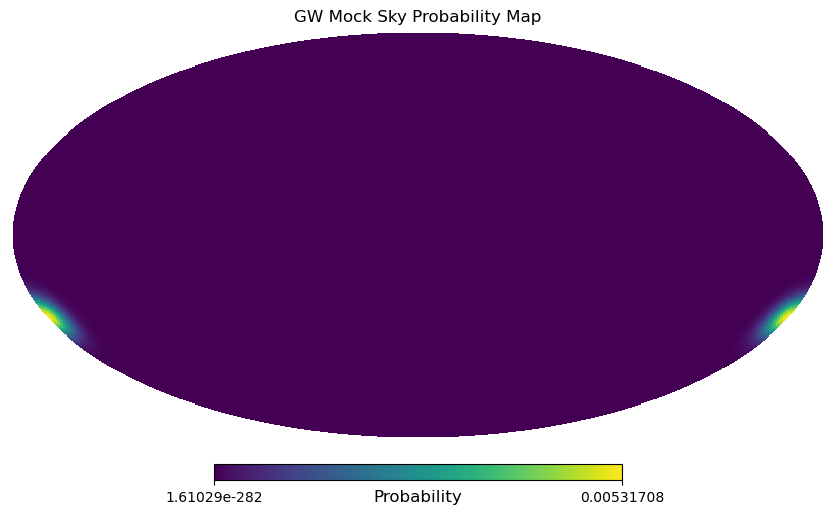

In [8]:
# -------------------------------------------------------------
# 2. Compute 50% and 90% Credible Regions
# -------------------------------------------------------------
# Sort pixels by probability in descending order
sorted_indices = np.argsort(prob_map)[::-1]
sorted_prob = prob_map[sorted_indices]
cum_prob = np.cumsum(sorted_prob)

# Identify pixels within 50% and 90% confidence limits
pix_50 = sorted_indices[cum_prob <= 0.50]
pix_90 = sorted_indices[cum_prob <= 0.90]

area_per_pix = hp.nside2pixarea(nside, degrees=True)
print(f"50% Credible Region Area: {len(pix_50) * area_per_pix:.2f} deg^2")
print(f"90% Credible Region Area: {len(pix_90) * area_per_pix:.2f} deg^2")

# Visualization: Sky map probability plot
hp.mollview(prob_map, title="GW Mock Sky Probability Map", unit="Probability")
plt.show()


In [9]:
# -------------------------------------------------------------
# 3. Telescope Tiling & Probability Ranking
# -------------------------------------------------------------
# Define a grid of telescope tiles (Field of View = 2.0 x 2.0 degrees = 4.0 sq deg)
fov_deg = 2.0 
tile_ras = np.arange(160, 200, fov_deg)
tile_decs = np.arange(-45, -15, fov_deg)

tile_results = []

for tra in tile_ras:
    for tdec in tile_decs:
        # Find pixels falling inside this telescope field
        in_tile = (ra >= tra) & (ra < tra + fov_deg) & (dec >= tdec) & (dec < tdec + fov_deg)
        total_p = np.sum(prob_map[in_tile])
        tile_results.append({'ra': tra + fov_deg/2, 'dec': tdec + fov_deg/2, 'prob': total_p})

# Sort tiles by integrated probability
tile_results = sorted(tile_results, key=lambda x: x['prob'], reverse=True)

print("\n--- Top 3 Priority Telescope Pointing Tiles ---")
for i, tile in enumerate(tile_results[:3]):
    print(f"Rank {i+1}: RA = {tile['ra']:.2f}°, Dec = {tile['dec']:.2f}° | Integrated Prob = {tile['prob']*100:.2f}%")



--- Top 3 Priority Telescope Pointing Tiles ---
Rank 1: RA = 181.00°, Dec = -30.00° | Integrated Prob = 2.62%
Rank 2: RA = 177.00°, Dec = -32.00° | Integrated Prob = 2.16%
Rank 3: RA = 183.00°, Dec = -32.00° | Integrated Prob = 2.16%


In [10]:

# -------------------------------------------------------------
# 4. Observability Filter (Visibility from Observatory)
# -------------------------------------------------------------
# Palomar Observatory Location; Change your location here 
palomar = EarthLocation(lat=33.356*u.deg, lon=-116.863*u.deg, height=1706*u.m)
obs_time = Time('2026-09-08 04:00:00')  # Observing time during workshop week

top_tile = tile_results[0]
target_coord = SkyCoord(ra=top_tile['ra']*u.deg, dec=top_tile['dec']*u.deg)
altaz = target_coord.transform_to(AltAz(obstime=obs_time, location=palomar))

print(f"\nTarget Field Position at {obs_time}:")
print(f"Altitude: {altaz.alt:.2f} | Zenith Angle: {90*u.deg - altaz.alt:.2f}")
if altaz.alt > 30*u.deg:
    print("Status: OBSERVABLE (Altitude > 30°)")
else:
    print("Status: NOT OBSERVABLE (Too low on horizon)")


Target Field Position at 2026-09-08 04:00:00.000:
Altitude: -30.78 deg | Zenith Angle: 120.78 deg
Status: NOT OBSERVABLE (Too low on horizon)
